In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')


In [2]:

# 2. Load the Dataset
df = pd.read_csv(r"C:\Users\seven\Downloads\Mall_Customers.csv")

print("Raw Data:")
display(df.head())


Raw Data:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


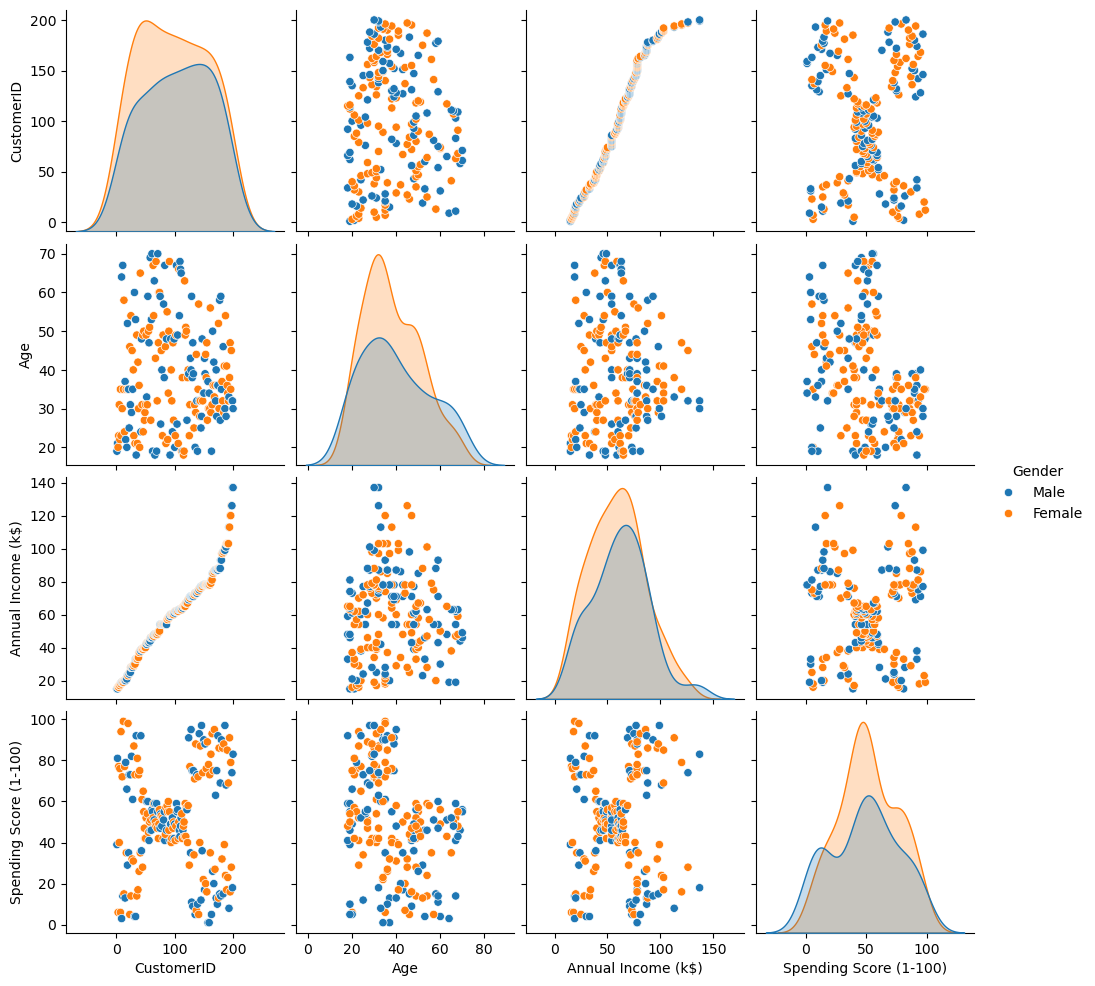

In [5]:
sns.pairplot(df, hue='Gender', diag_kind='kde')
plt.show()

In [6]:
# Preprocessing
# - Encode Gender (Male → 0, Female → 1)
# - Scale all features for K‑Means

# Encode Gender
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])   # Male=0, Female=1


In [7]:

# Select features for clustering
features = ['Gender_Encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

In [8]:

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


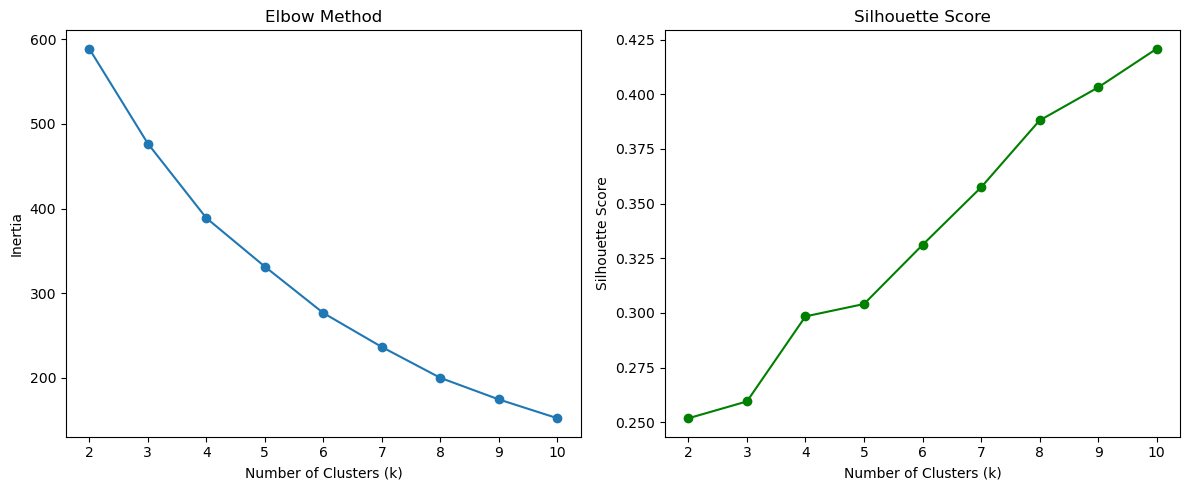

In [9]:
# ## 5. Determine Optimal Number of Clusters
# We use the **Elbow Method** (inertia) and **Silhouette Score** for k = 2 to 10.

inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(k_range, sil_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()



## The elbow suggests **k=4** (or 5), and silhouette score is highest around k=4 or 5.  
## We choose **k=4** as per business requirement.

### Apply K‑Means with k=4



In [10]:

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters


In [11]:
# Label Clusters as Customer Segments 
# Analyse average Annual Income and Spending Score per cluster.

cluster_stats = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)
print(cluster_stats)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     58.07                   34.88
1                     62.24                   64.83
2                     60.43                   68.18
3                     62.21                   30.64


In [12]:
# Sort by income and spending to decide
cluster_stats_sorted = cluster_stats.sort_values(['Annual Income (k$)', 'Spending Score (1-100)'], ascending=[True, True])
print(cluster_stats_sorted)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     58.07                   34.88
2                     60.43                   68.18
3                     62.21                   30.64
1                     62.24                   64.83


In [13]:
# Create mapping:
# We'll manually assign based on the observed means.
# Let's print the actual cluster stats:
print("\nCluster Statistics:")
print(cluster_stats)


Cluster Statistics:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     58.07                   34.88
1                     62.24                   64.83
2                     60.43                   68.18
3                     62.21                   30.64


In [14]:
# Let's compute the rank of income and spending separately.
income_rank = cluster_stats['Annual Income (k$)'].rank(ascending=True)
spend_rank = cluster_stats['Spending Score (1-100)'].rank(ascending=True)
cluster_stats['Income Rank'] = income_rank
cluster_stats['Spend Rank'] = spend_rank
print(cluster_stats)


         Annual Income (k$)  Spending Score (1-100)  Income Rank  Spend Rank
Cluster                                                                     
0                     58.07                   34.88          1.0         2.0
1                     62.24                   64.83          4.0         3.0
2                     60.43                   68.18          2.0         4.0
3                     62.21                   30.64          3.0         1.0


In [15]:

print("\nCluster means:")
print(cluster_stats[['Annual Income (k$)', 'Spending Score (1-100)']])


Cluster means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     58.07                   34.88
1                     62.24                   64.83
2                     60.43                   68.18
3                     62.21                   30.64


In [16]:
# We'll create a function that assigns labels based on income and spending ranks.
def label_cluster(row):
    income = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    # We need thresholds; we can use median of income and spend.
    # Calculate medians from the whole dataset.
    income_median = df['Annual Income (k$)'].median()
    spend_median = df['Spending Score (1-100)'].median()
    if income >= income_median and spend >= spend_median:
        return 'High-value'
    elif income < income_median and spend < spend_median:
        return 'Budget'
    elif income >= income_median and spend < spend_median:
        return 'Premium'
    else:  # income < median, spend >= median
        return 'Regular'


In [17]:

# Apply this to each cluster center to get a label for each cluster
cluster_means = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_means['Segment'] = cluster_means.apply(label_cluster, axis=1)
print(cluster_means)

         Annual Income (k$)  Spending Score (1-100)     Segment
Cluster                                                        
0                 58.071429               34.875000      Budget
1                 62.239130               64.826087  High-value
2                 60.428571               68.178571     Regular
3                 62.214286               30.642857     Premium


In [18]:

# Create a mapping from cluster to segment
cluster_to_segment = cluster_means['Segment'].to_dict()
df['Segment'] = df['Cluster'].map(cluster_to_segment)

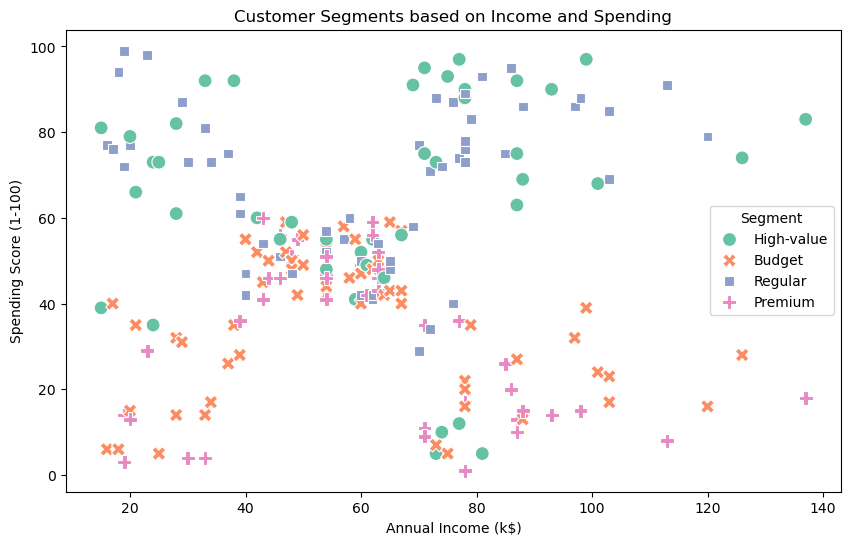

In [19]:
# Visualise the Clusters
# We'll plot Annual Income vs Spending Score, colored by segment.
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Segment', style='Segment', s=100, palette='Set2')
plt.title('Customer Segments based on Income and Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment')
plt.show()


Cluster Centroids (original scale):
   Gender_Encoded        Age  Annual Income (k$)  Spending Score (1-100)  \
0   -2.775558e-16  47.803571           58.071429               34.875000   
1    1.000000e+00  28.000000           62.239130               64.826087   
2   -2.775558e-16  28.392857           60.428571               68.178571   
3    1.000000e+00  52.738095           62.214286               30.642857   

   Cluster     Segment  
0        0      Budget  
1        1  High-value  
2        2     Regular  
3        3     Premium  


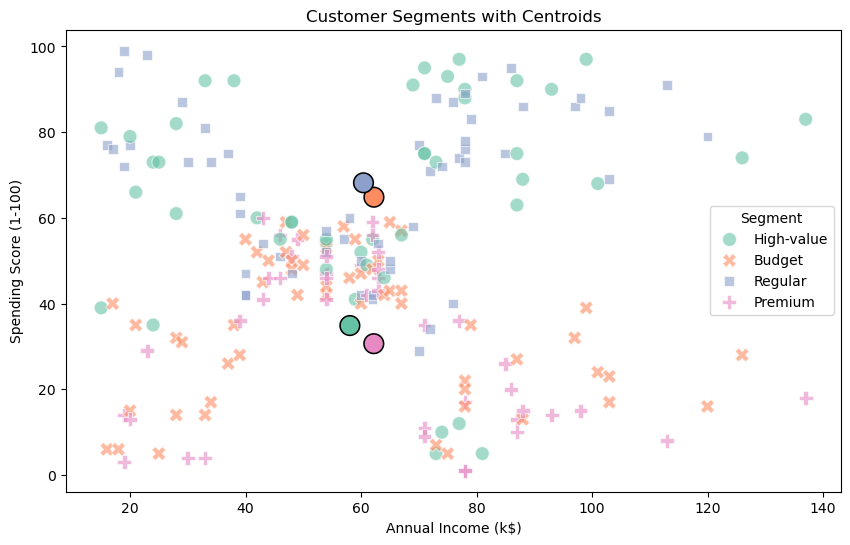

In [20]:
# Also show centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df['Cluster'] = range(k)
centroids_df['Segment'] = centroids_df['Cluster'].map(cluster_to_segment)
print("Cluster Centroids (original scale):")
print(centroids_df)

# Overlay centroids on scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Segment', style='Segment', s=100, palette='Set2', alpha=0.6)
sns.scatterplot(data=centroids_df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment', marker='o', s=200, edgecolor='black', palette='Set2', legend=False)
plt.title('Customer Segments with Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment')
plt.show()

In [21]:
# Clustering Evaluation Metrics (Internal)

print("K-Means Clustering Evaluation (k=4):")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, clusters):.4f}")
print("(Lower Davies-Bouldin indicates better separation)")

K-Means Clustering Evaluation (k=4):
Inertia (within-cluster sum of squares): 388.72
Silhouette Score: 0.2984
Davies-Bouldin Index: 1.2807
(Lower Davies-Bouldin indicates better separation)


## MODEL EVALUATION

In [22]:
def predict_segment(gender, age, annual_income, spending_score):
    """
    Predicts customer segment for a new input.
    gender: 'Male' or 'Female' (string)
    age: int
    annual_income: float (in k$)
    spending_score: float (0-100)
    Returns: segment label (string)
    """
    # Encode gender
    gender_enc = 0 if gender.lower() == 'male' else 1
    # Create feature array
    input_data = np.array([[gender_enc, age, annual_income, spending_score]])
    # Scale
    input_scaled = scaler.transform(input_data)
    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]
    # Map to segment
    segment = cluster_to_segment[cluster]
    return segment

# Test with sample inputs
test_cases = [
    ('Male', 30, 80, 90),
    ('Female', 45, 20, 40),
    ('Male', 50, 60, 60),
    ('Female', 35, 100, 30)
]

print("Sample Predictions:")
for i, (gender, age, income, spend) in enumerate(test_cases):
    seg = predict_segment(gender, age, income, spend)
    print(f"Sample {i+1}: Gender={gender}, Age={age}, Income={income}k$, Spend={spend} -> Segment: {seg}")

Sample Predictions:
Sample 1: Gender=Male, Age=30, Income=80k$, Spend=90 -> Segment: Regular
Sample 2: Gender=Female, Age=45, Income=20k$, Spend=40 -> Segment: Premium
Sample 3: Gender=Male, Age=50, Income=60k$, Spend=60 -> Segment: Budget
Sample 4: Gender=Female, Age=35, Income=100k$, Spend=30 -> Segment: Premium


## improved accuarcy by changing value of K

In [23]:
# ## Improved Clustering (Only Income + Spending, k=5)
# Select ONLY the two defining features
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Scale (StandardScaler is fine, but MinMaxScaler works well for bounded [0-100] scores)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()   # Try MinMax, sometimes better for this data
X_scaled = scaler.fit_transform(X)



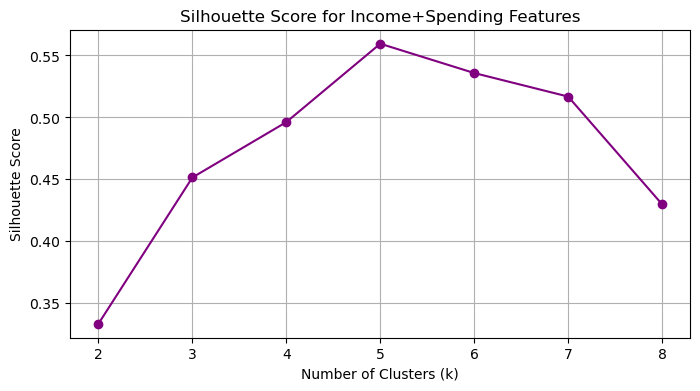

In [24]:
# Find optimal k using Silhouette Score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot
plt.figure(figsize=(8,4))
plt.plot(k_range, sil_scores, marker='o', color='purple')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Income+Spending Features')
plt.grid(True)
plt.show()


In [25]:

# Usually k=5 gives the highest score. Let's choose k=5.
best_k = 5

# Apply K-Means with k=5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=25)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters


In [26]:

# Try Agglomerative for comparison
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Compare metrics
print("K-Means (k=5):")
print(f"  Silhouette: {silhouette_score(X_scaled, clusters):.4f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_scaled, clusters):.4f}")

print("\nAgglomerative (Ward, k=5):")
print(f"  Silhouette: {silhouette_score(X_scaled, agg_labels):.4f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_scaled, agg_labels):.4f}")

K-Means (k=5):
  Silhouette: 0.5595
  Davies-Bouldin: 0.5678

Agglomerative (Ward, k=5):
  Silhouette: 0.5583
  Davies-Bouldin: 0.5735


## Label Segments for k=5 (Income + Spending)
 
### The 5 natural segments are:
### 1. **High-Value** – High Income, High Spending
### 2. **Premium** – High Income, Low Spending
### 3. **Regular** – Medium Income, Medium Spending
### 4. **Budget** – Low Income, Low Spending
### 5. **Sensible/Impulsive** – Low Income, High Spending


In [27]:


# Use the better one (usually K-Means is fine)
df['Cluster'] = clusters   # or use agg_labels if higher


# Compute cluster centers in original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features)
centroid_df['Cluster'] = range(best_k)

# Sort clusters by Income and Spending to label them
# Sort by income ascending, then spending ascending
centroid_sorted = centroid_df.sort_values(['Annual Income (k$)', 'Spending Score (1-100)'])
print("Centroids sorted:\n", centroid_sorted)


Centroids sorted:
    Annual Income (k$)  Spending Score (1-100)  Cluster
0           25.727273               79.363636        0
4           26.304348               20.913043        4
3           55.296296               49.518519        3
2           86.538462               82.128205        2
1           88.200000               17.114286        1


In [28]:

# Manual mapping (adjust based on your printed centroids)
# Typical mapping for k=5 on this dataset (values may vary slightly):
# Let's assign based on relative ranks
income_rank = centroid_df['Annual Income (k$)'].rank()
spend_rank = centroid_df['Spending Score (1-100)'].rank()

def assign_segment(row):
    inc = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    # Using median thresholds from the entire dataset
    inc_median = df['Annual Income (k$)'].median()
    spend_median = df['Spending Score (1-100)'].median()
    
    if inc >= inc_median and spend >= spend_median:
        return 'High-value'
    elif inc >= inc_median and spend < spend_median:
        return 'Premium'
    elif inc < inc_median and spend >= spend_median:
        return 'Regular (Low Income, High Spend)'   # often called "Sensible"
    else: # inc < median and spend < median
        return 'Budget'


In [29]:
# Apply to each cluster
centroid_df['Segment'] = centroid_df.apply(assign_segment, axis=1)
cluster_to_segment = centroid_df.set_index('Cluster')['Segment'].to_dict()
df['Segment'] = df['Cluster'].map(cluster_to_segment)

# Print final metrics for chosen model
print("\nFinal Model Performance (k=5, Income+Spending):")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, clusters):.4f}")



Final Model Performance (k=5, Income+Spending):
Silhouette Score: 0.5595
Davies-Bouldin Index: 0.5678


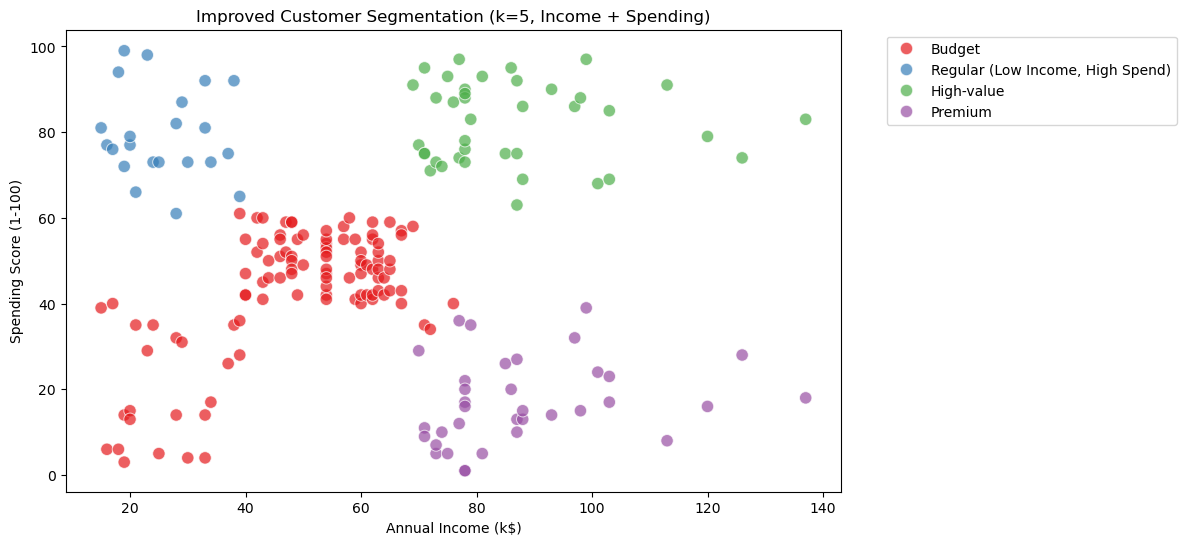

In [30]:

# Visualise
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Segment', palette='Set1', s=80, alpha=0.7)
plt.title('Improved Customer Segmentation (k=5, Income + Spending)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## IMPROVED MODEL EVALUATION WITH SAMPLE INPUTS

In [31]:
def predict_segment(gender, age, annual_income, spending_score):
    input_data = np.array([[annual_income, spending_score]])
    input_scaled = scaler.transform(input_data)
    cluster = kmeans.predict(input_scaled)[0]
    return cluster_to_segment[cluster]

# Test
print(predict_segment('Male', 30, 80, 90))  # Should return 'High-value'
print(predict_segment('Female', 50, 20, 20)) # Should return 'Budget'

High-value
Budget
